# Spike Train Reproduction Post-Experiment Text Analysis

In [1]:
%reload_ext autoreload
%autoreload 2

# Imports
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from tqdm import tqdm
import pickle
import src.utils.preprocess as preprocess
# import src.utils.sigmoid as sigmoid
from scipy.io import savemat, loadmat
from scipy.signal import convolve2d
import re
import visionloader as vl
import sta_utils as su
from scipy.spatial import ConvexHull
import src.utils.cellmap as cellmap
import src.utils.encoding_decoding_simulation_pooled as edsp
from scipy.ndimage import gaussian_filter
from matplotlib.patches import Ellipse
from PIL import Image
import multiprocessing
from multiprocessing import Pool
import warnings
from PIL import Image, ImageDraw, ImageFont

import sys
sys.path.append('/Volumes/Lab/Users/ajphillips/greedy/src/')
import sigmoid

Paths

In [2]:
piece = '2024-10-02-7'
analysis_base = f"/Volumes/Stream/Analysis/RETINA/{piece}"
pp_base = analysis_base
gsort_base = analysis_base
espont_base = analysis_base
pickle_path_base = "gsort_single_v2"
label = "_3"
text_label = "_text_3"

In [577]:
# Load text info
spike_trains = np.load(f"{analysis_base}/dictionary/spike_trains{text_label}.npz", allow_pickle=True)
text = spike_trains['text']
order = spike_trains['order']
for i in range(len(text)):
    print(f"Text {i}: {text[i]} {order[i]}")

Text 0: I LOVE YOU [ 545 4488 1401 2523 7175 2416 5626 3017  918   46 2117  858 2131   48
 3706  406 5506]
Text 1: BROOKE [ 545 4488 1401 2523 7175 2416 5626 3017  918   46 2117  858 2131   48
 3706  406 5506]
Text 2: STANFORD [ 545 4488 1401 2523 7175 2416 5626 3017  918   46 2117  858 2131   48
 3706  406 5506]
Text 3: RETINA [ 545 4488 1401 2523 7175 2416 5626 3017  918   46 2117  858 2131   48
 3706  406 5506]
Text 4: SPIKES [ 545 4488 1401 2523 7175 2416 5626 3017  918   46 2117  858 2131   48
 3706  406 5506]
Text 5: VISION [ 545 4488 1401 2523 7175 2416 5626 3017  918   46 2117  858 2131   48
 3706  406 5506]
Text 6: PHILLIPS ET AL [ 545 4488 1401 2523 7175 2416 5626 3017  918   46 2117  858 2131   48
 3706  406 5506]
Text 7: ZAPIS DU KARTY [ 545 4488 1401 2523 7175 2416 5626 3017  918   46 2117  858 2131   48
 3706  406 5506]
Text 8: NEURONS [ 545 4488 1401 2523 7175 2416 5626 3017  918   46 2117  858 2131   48
 3706  406 5506]
Text 9: NATURE BME [ 545 4488 1401 2523 7175 2416 

In [1174]:
frame_no = 8
estim_trial = 2
estim = f"data013/frame_{frame_no}"
espont = "data013_from_data000"
wnoise = "data000"
cell_types = ['ON parasol', 'OFF parasol']

wnoise_path = os.path.join(analysis_base, wnoise)
pp_path = os.path.join(pp_base, estim)
gsort_path = os.path.join(gsort_base, "gsort", estim, wnoise)
espont_path = os.path.join(espont_base, espont)

Single electrode scan info:

In [1175]:
wn1 = 'data000'
estim1 = 'data006'
wn2 = 'data000'
estim2 = 'data014'

Load dictionary

In [1176]:
# The dictionary and associated data is stored in this directory
# Much of the data/analysis associated with the experiment exists in the parent directory
dict_path = os.path.join(analysis_base, "dictionary")

# Load relevant data from .npz files
with np.load(os.path.join(dict_path,f"selective_stimuli{label}.npz")) as data:
    selective_stimuli = data["selective_stimuli"]
with np.load(os.path.join(dict_path,f"{wnoise}_bundle_thresholds.npz")) as data:
    bundle_thresholds = data["bundle_thresholds"]

print(selective_stimuli.shape)
print(bundle_thresholds.shape)

np.set_printoptions(suppress=True)
print(selective_stimuli)

(129, 4)
(519, 2)
[[   9.           46.            3.74472908    1.        ]
 [  13.          406.            3.61979944    1.        ]
 [  17.          286.            2.4938346     1.        ]
 [  20.          286.            2.25968273    1.        ]
 [  24.          406.            3.74741533    1.        ]
 [  25.          286.            3.11606282    1.        ]
 [  26.          406.            3.57548245    1.        ]
 [  27.          406.            3.7587682     1.        ]
 [  33.          406.            3.72818058    1.        ]
 [  36.          545.            3.28675444    1.        ]
 [  45.          918.            3.55396571    1.        ]
 [  46.          545.            3.52323808    1.        ]
 [  49.          858.            1.96997268    1.        ]
 [  50.         1401.            2.8013629     1.        ]
 [  54.          918.            3.7063111     1.        ]
 [  58.          858.            2.95609343    1.        ]
 [  64.         5506.            3.174

In [1177]:
vcd = vl.load_vision_data(wnoise_path,wn1,
                        include_neurons=True,
                        include_ei=True,
                        include_params=True,
                        include_runtimemovie_params=True)

all_cells_of_interest = []
for cell_type in cell_types:
    all_cells_of_interest += vcd.get_all_cells_similar_to_type(cell_type)
all_cells_of_interest = np.array(all_cells_of_interest)

print(f"Total cells of type {cell_types}: {all_cells_of_interest.size}")

Total cells of type ['ON parasol', 'OFF parasol']: 47


Count the delivered stimuli

In [1178]:
# The electrical stimulation scans are stored in this directory
# Much of the data/analysis associated with the experiment exists in the parent directory
path = os.path.join(analysis_base, "estim")

# Read in .mat file
ppinfo = loadmat(os.path.join(path,f"preprocessing_info{text_label}.mat"))
experiment_boundaries, experiment_names = ppinfo["experimentBoundaries"], ppinfo["experimentNames"]
print(f"Experiment boundaries shape {experiment_boundaries.shape}")

with open(os.path.join(path,f"spike_trains{text_label}.sef"), "rb") as f:
    sef = np.fromfile(f, dtype=np.int32)
    sef = np.reshape(sef, (int(len(sef)/3), 3), order='F')

sef_of_interest = sef[experiment_boundaries[frame_no,estim_trial*2+0]-1:experiment_boundaries[frame_no,estim_trial*2+1],:] # Assume 2D matrix called 'experimentBoundaries' of size |nExperiments|x|2*nBoundaries|

unique_stimuli, count_stimuli = np.unique(sef_of_interest[:,1:], axis=0, return_counts=True)
unique_times, count_times = np.unique(sef_of_interest[:,0], return_counts=True)

Experiment boundaries shape (10, 30)


In [1179]:
print(f"{unique_stimuli.shape[0]} unique stimuli")
print(f"{unique_times.shape[0]} stimulation events")

print(sum(count_stimuli), "total stimulations")
print(f"Duration {(sef_of_interest[-1,0] - sef_of_interest[0,0]) / 20} ms")

17 unique stimuli
99 stimulation events
264 total stimulations
Duration 250.0 ms


### Load electrically evoked spike trains

In [1180]:
def flip(cell, pattern, amp, flip_prob=0.9, plot=False):

    gsort_path_base1 = os.path.join(gsort_base, "gsort", estim1)
    gsort_path_base2 = os.path.join(gsort_base, "gsort", estim2)

    patterns = sigmoid.find_activating_patterns(gsort_path_base1, cell)
    patterns = np.sort(patterns)
    pattern_nos = [int(p.split('p')[-1]) for p in patterns]
    
    if pattern not in pattern_nos:
        raise Exception("Pattern not found in gsort_path_base1")

    pattern = f"p{pattern}"

    try:
        if plot:
            fig, ax = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(5,5))

        amps1, probs1, slp1, thr1, std1, success1 = sigmoid.compute_sigmoid(gsort_path_base1, pickle_path_base, cell, pattern, plot=False)
        
        if plot:
            sigmoid.plot_sigmoid(ax, amps1, probs1, slp1, thr1, 'k')

        try:
            amps2, probs2, slp2, thr2, std2, success2 = sigmoid.compute_sigmoid(gsort_path_base2, pickle_path_base, cell, pattern) # mapping['forward'][cell]

            if plot:
                sigmoid.plot_sigmoid(ax, amps2, probs2, slp2, thr2, 'b')

        except Exception as e:
            if plot:
                ax.text(0.1,0.9,str(e))
            else:
                raise e

    except Exception as ex:
        if plot:
            ax.text(0.1,0.1,str(ex))
        else:
            raise ex
    
    if plot:
        ax.set_xlim(0,4)
        ax.set_ylim(0,1)
        ax.set_xlabel('Stimulation Amplitude (uA)')
        ax.set_ylabel('Activation Probability')
        ax.set_title(f"{piece} cell {cell} electrode {pattern[1:]}")
        plt.show()

    # Perform disambiguation
    # print(f"calibration prob {probs1[amp-1]}, bookend prob {probs2[amp-1]}, flipping {probs2[amp-1] > flip_prob}")
    if probs2[amp-1] > flip_prob:
        return True
    else:
        return False

In [1181]:
def amps_to_indices(amps):
    AMPS = np.array([0.09375, 0.1875, 0.28125, 0.375, 0.46875, 0.5625, 0.65625, 0.75, 0.84375, 0.9375,
        1.03125, 1.125, 1.21875, 1.3125, 1.40625, 1.5, 1.59375, 1.6875, 1.78125, 1.875, 1.96875,
        2.0625, 2.15625, 2.25, 2.34375, 2.4375, 2.53125, 2.625, 2.71875, 2.8125, 2.90625, 3.0,
        3.09375, 3.1875, 3.28125, 3.375, 3.46875, 3.5625, 3.65625, 3.75, 3.84375, 3.9375])
    return np.array([np.argmin(np.abs(AMPS - amp)) + 1 for amp in amps]) # 1-indexed

def boolean_spikes(gsort_path_base, pickle_path_base, cell, pattern, k):
    # Set the random number seed for reproducibility of edge case behavior
    np.random.seed(cell+int(pattern[1:]))

    gsort_path = f"{gsort_path_base}/{pattern}/"
   
    pickle_path = f"{pickle_path_base}_n{cell}_{pattern}_k{k}.pkl"
    with open(gsort_path + pickle_path, 'rb') as f:
        prob_dict = pickle.load(f)
        
        cosine_prob, prob, initial_clustering_with_virtual, final_clustering, graph_info = prob_dict['cosine_prob'], prob_dict['prob'], prob_dict['initial_clustering_with_virtual'], prob_dict['final_clustering'], prob_dict['graph_info']

        cosine_prob = cosine_prob[0]
        graph_info = graph_info[2]
        final_clustering = final_clustering[0]

        # print(cosine_prob)
        # print(prob)
        # print(graph_info)
        # print(initial_clustering_with_virtual)

        if np.isclose(cosine_prob, 0, rtol=0, atol=1e-5):
            bool_spikes = [False for _ in initial_clustering_with_virtual]
            # print(bool_spikes)
            # print(sum(bool_spikes)/len(bool_spikes))
            return bool_spikes

        # get index of dictionary entry with the value cell
        edges = [*graph_info]
        edge = get_key(graph_info, cell)
        # print(edge)
        # print(edges)
        path = []
        for e in edge:
            path.extend(get_path(edges, edges.index(e)))

        # print(path)

        if np.isclose(cosine_prob, prob, rtol=0, atol=1e-5):
            bool_spikes = [spike in path for spike in initial_clustering_with_virtual]
            # print(bool_spikes)
            # print(sum(bool_spikes)/len(bool_spikes))
            return bool_spikes
        

        all_possible_edges = []
        difference = np.round(np.abs(cosine_prob - prob)*len(initial_clustering_with_virtual)).astype(int)
        # print(difference)

        for e in edge:
            _ = find_cosine_path(edges, edges.index(e), initial_clustering_with_virtual, all_possible_edges, difference)
        # print(all_possible_edges)

        if len(all_possible_edges) > 1:
            warnings.warn("Ambiguous cosine similarity single path removal") # we cannot infer which edge was removed, arbitrarily guess the first one
        elif len(all_possible_edges) == 0:
            warnings.warn("No valid cosine similarity single path removal") # indicating multiple edges have been removed, randomly assign the spikes
            
            # Build a randomly shuffled list of booleans corresponding to the cosine probability
            bool_spikes = [True if i < np.round(cosine_prob*len(initial_clustering_with_virtual)).astype(int) else False for i in range(len(initial_clustering_with_virtual))]
            np.random.shuffle(bool_spikes)

            # print(bool_spikes)
            # print(sum(bool_spikes)/len(bool_spikes))
            return bool_spikes
        
        removal_path = get_path(edges, edges.index(all_possible_edges[0]))
        # print(removal_path)

        bool_spikes = [spike in path and spike not in removal_path for spike in initial_clustering_with_virtual]
        # print(bool_spikes)
        # print(sum(bool_spikes)/len(bool_spikes))
        
        return bool_spikes


def get_key(my_dict, val):
    keys = []
   
    for key, value in my_dict.items():
        if val == value:
            keys.append(key)

    if len(keys) == 0:
        raise ValueError("Cell not assigned to any edge")

    return keys

def get_path(edges, start_index):
    path = []
    path.append(edges[start_index][1])

    for i in range(len(edges)):
        if edges[i][0] == edges[start_index][1]:
            path.extend(get_path(edges, i))

    return path
    
def find_cosine_path(edges, start_index, initial_clustering_with_virtual, all_possible_edges, difference):

    count = 0
    for i in range(len(edges)):
        if edges[i][0] == edges[start_index][1]:
            count += find_cosine_path(edges, i, initial_clustering_with_virtual, all_possible_edges, difference)
    
    total = np.sum(edges[start_index][1] == initial_clustering_with_virtual) + count
    if total == difference:
        all_possible_edges.append(edges[start_index])
    return total

def transform_to_519(electrode):
    skip_elecs = np.array([1, 130, 259, 260, 389, 390, 519])
    elecs = np.arange(1, 520)
    elecs = elecs[~np.isin(elecs, skip_elecs)]
    return elecs[electrode-1]


In [1182]:
spikes = {}
probabilities = {}

initial_spikes = {}
initial_probabilities = {}

mismatch = False

for t in tqdm(range(unique_times.shape[0])):
    # print(f"PATTERN {t+1}")

    # Set up nested dictionaries
    initial_spikes[t] = {}
    initial_probabilities[t] = {}
    spikes[t] = {}
    probabilities[t] = {}

    # Identify all electrical stimuli delivered simultaneously at time t
    stim = sef_of_interest[np.where(sef_of_interest[:,0] == unique_times[t])[0],1:]

    for s in stim:

        if (s[0] == 8) & (s[1] == 38):
            s[1] = 40
            print("Undiagnosed problem, changed 8,38 to 8,40 to find the correct cell")
            mismatch = True

        # Find the row of selective_stimuli corresponding to each electrical stimulus
        # selective_stimulus = selective_stimuli[np.where((selective_stimuli[:,0] == transform_to_519(s[0])) & (amps_to_indices(selective_stimuli[:,2]) == s[1]))[0][0]]
        selective_stimulus = selective_stimuli[np.where(selective_stimuli[:,0] == transform_to_519(s[0]))[0][0]]
        # print(selective_stimulus)

        # Look for electrical spike sorting results at the time-pattern for each targeted cell (only ever one movie per time-pattern)
        c = int(selective_stimulus[1])
        # print(f"Cell {c}")
        bs = boolean_spikes(gsort_path, pickle_path_base, c, f"p{t+1}", 0)

        initial_spikes[t][c] = bs
        initial_probabilities[t][c] = np.mean(bs)

        # print(bs)
        # print(np.mean(bs))

        # If the selective stimulus was pure (we expected the cell to spike with ~100% probability) and gsort returns ~0% probability,
        # cross reference with the bookend single-electrode scan to decide how to disambiguate
        # Assumes that multi-electrode stimulation does not significantly alter the single-electrode activation curve
        # Ask Amrith about explanation for 0.1
        # _ = flip(c, s[0], s[1], flip_prob=0.9, plot=True)

        if mismatch:
            s[1] = 38
            print("Reverting 8,40 to 8,38")
            mismatch = False

        if int(selective_stimulus[3]) and (np.mean(bs) < 0.1): 
            if flip(c, transform_to_519(s[0]), s[1], flip_prob=0.8, plot=False): 
                bs = [not b for b in bs]

        spikes[t][c] = bs
        probabilities[t][c] = np.mean(bs)

    #     print(bs)
    #     print(np.mean(bs))

    # print("=================================")


In [1183]:
for t in tqdm(range(unique_times.shape[0])):
    # Identify all electrical stimuli delivered simultaneously at time t
    stim = sef_of_interest[np.where(sef_of_interest[:,0] == unique_times[t])[0],1:]
    
    for s in stim:
        if transform_to_519(s[0]) == 9:
            print(stim)

100%|██████████| 99/99 [00:00<00:00, 2870.13it/s]

[[148  25]
 [359  15]
 [ 57  32]
 [ 44  38]
 [ 35  35]
 [275  22]
 [  8  38]
 [283  28]]
[[437  36]
 [189  28]
 [148  25]
 [275  22]
 [  8  40]]
[[437  36]
 [ 44  38]
 [275  22]
 [  8  40]]
[[437  36]
 [275  22]
 [  8  40]]
[[359  15]
 [275  22]
 [  8  40]]
[[114  27]
 [275  22]
 [  8  40]]
[[160  29]
 [189  28]
 [148  25]
 [275  22]
 [  8  40]
 [283  28]
 [ 97  26]]
[[160  29]
 [  8  40]]
[[189  28]
 [148  25]
 [498  31]
 [ 35  35]
 [  8  38]
 [283  28]
 [ 97  26]]
[[148  25]
 [359  15]
 [ 57  32]
 [ 44  38]
 [ 35  35]
 [275  22]
 [  8  38]
 [283  28]]
[[437  36]
 [275  22]
 [  8  40]]
[[160  29]
 [ 44  38]
 [  8  40]]


In [1184]:
print(sef_of_interest[np.where(sef_of_interest[:,1] == 8)[0]])

[[1605401       8      38]
 [1605801       8      40]
 [1606101       8      40]
 [1606751       8      40]
 [1607201       8      40]
 [1607451       8      40]
 [1607851       8      40]
 [1608201       8      40]
 [1608551       8      38]
 [1608901       8      38]
 [1609301       8      40]
 [1609601       8      40]]


In [1185]:
print(text[frame_no])

NEURONS


Missing cells: [3017]
Cell 3017 not found in spike times


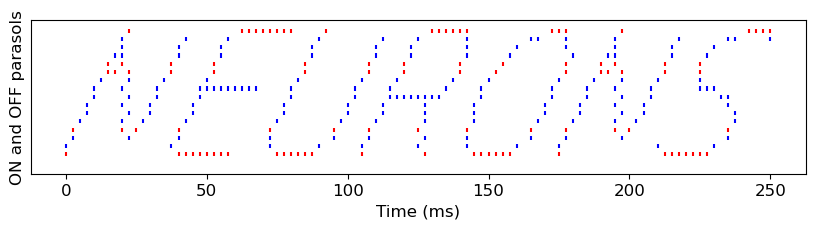

In [1186]:
import collections

# Read the intended spike times from the SEF file and display it as a spike raster plot
all_spike_times = sef_of_interest[:,0] / 20

# Find out which cell ID corresponds to each targeted electrode using selective_stimuli
# all_spike_cells = [selective_stimuli[np.where((selective_stimuli[:,0] == e) & (amps_to_indices(selective_stimuli[:,2]) == a))[0][0],1] for e,a in zip([transform_to_519(e) for e in sef_of_interest[:,1]], sef_of_interest[:,2])]
all_spike_cells = [selective_stimuli[np.where(selective_stimuli[:,0] == e)[0][0],1] for e,a in zip([transform_to_519(e) for e in sef_of_interest[:,1]], sef_of_interest[:,2])]
all_spike_cells = np.array(all_spike_cells).astype(int)

# Create a dictionary of spike times for each cell
spike_times = {}
for i in range(len(all_spike_cells)):
    if all_spike_cells[i] not in spike_times:
        spike_times[all_spike_cells[i]] = []
    spike_times[all_spike_cells[i]].append(all_spike_times[i])

# For STANFORD 51
modified_spike_times = {}
for i in range(len(all_spike_cells)):
    if all_spike_cells[i] not in modified_spike_times:
        modified_spike_times[all_spike_cells[i]] = []
    if all_spike_times[i]-sef_of_interest[0,0]/20 >= 0:
        modified_spike_times[all_spike_cells[i]].append(all_spike_times[i])

ordered_spike_times = []
true_order = []
# Find the true order of the cells
for cell in sorted(modified_spike_times, key=lambda x: min(modified_spike_times[x])):
    ordered_spike_times.append(spike_times[cell])
    true_order.append(cell)
true_order = np.array(true_order)


# # Put cell 46 at the front of true_order, leave the rest in order
# true_order = np.concatenate(([858], true_order[true_order != 858]))
# true_order = np.concatenate(([1401], true_order[true_order != 1401]))

# # Flip indices 8 and 9
# true_order = np.concatenate((true_order[:8], [true_order[9], true_order[8]], true_order[10:]))

# Flip indices 0 and 1
# true_order = np.concatenate(([true_order[1], true_order[0]], true_order[2:]))

# Put cell 2416 at the back of true_order, leave the rest in order
# true_order = np.concatenate((true_order[true_order != 2416], [2416]))

# For I LOVE YOU
# true_order = np.concatenate((true_order[true_order != 2416], [2416]))
# true_order = np.concatenate(([5626], true_order[true_order != 5626]))

# For BROOKE
# true_order = np.concatenate(([true_order[1], true_order[0]], true_order[2:]))
# true_order = np.concatenate(([5626], true_order[true_order != 5626]))

# For VISION
# true_order = np.concatenate(([858], true_order[true_order != 858]))
# true_order = np.concatenate(([1401], true_order[true_order != 1401]))
# true_order = np.concatenate((true_order[:8], [true_order[9], true_order[8]], true_order[10:]))

# For NEURONS
# [None]

# For STANFORD
# true_order = np.concatenate((true_order[-5:], true_order[:-5]))
# true_order = np.concatenate((true_order[true_order != 858], [858]))
# true_order = np.concatenate((true_order[:7], [true_order[8], true_order[7]], true_order[9:]))

# Add any cells from the original set that were not in the SEF file to the beginning of true order
original_order = order[0]
missing_cells = np.setdiff1d(original_order, true_order)
print(f"Missing cells: {missing_cells}")
true_order = np.concatenate((missing_cells, true_order))

ordered_spike_times = []
for cell in true_order:
    try:
        ordered_spike_times.append(np.array(spike_times[cell]))
    except KeyError:
        print(f"Cell {cell} not found in spike times")
        ordered_spike_times.append(np.array([]))
ordered_spike_times = np.array(ordered_spike_times, dtype=object)

colors = []
for cell in true_order:
    if cell in vcd.get_all_cells_similar_to_type('ON parasol'):
        colors.append('r')
    elif cell in vcd.get_all_cells_similar_to_type('OFF parasol'):
        colors.append('b')
    else:
        raise ValueError(f"Cell {cell} not found in parasol types")
colors = np.array(colors)

plt.figure(figsize=(10, 2))

# Create a spike raster plot
plt.eventplot(ordered_spike_times-sef_of_interest[0,0]/20, linelengths=0.5, colors=colors)

# Set the y-axis ticks and labels
plt.yticks(range(len(true_order)), true_order)
plt.ylabel('ON and OFF parasols', fontsize=12)

# Set the x-axis label
plt.xlabel('Time (ms)', fontsize=12)

# Make all ticks larger
plt.tick_params(axis='both', which='major', labelsize=12)

# Hide x-axis ticks
# plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

# Hide y-axis ticks
plt.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

# Set the plot title
# plt.title('Intended Spike Times')

# Show the plot
plt.show()

In [1187]:
selective_cells_of_interest = true_order
print(f"Total selective cells of interest of type {cell_types}: {selective_cells_of_interest.size}")

Total selective cells of interest of type ['ON parasol', 'OFF parasol']: 17


In [1188]:
# List of selective cells from spike_trains_3 datarun
selective_cells = np.array([46,48,286,406,545,858,918,1401,1922,1953,2088,2117,2131,2416,2523,2911,3017,3062,3616,3706,3994,4488,5506,5626,5873,6512,7175,7683,7726])

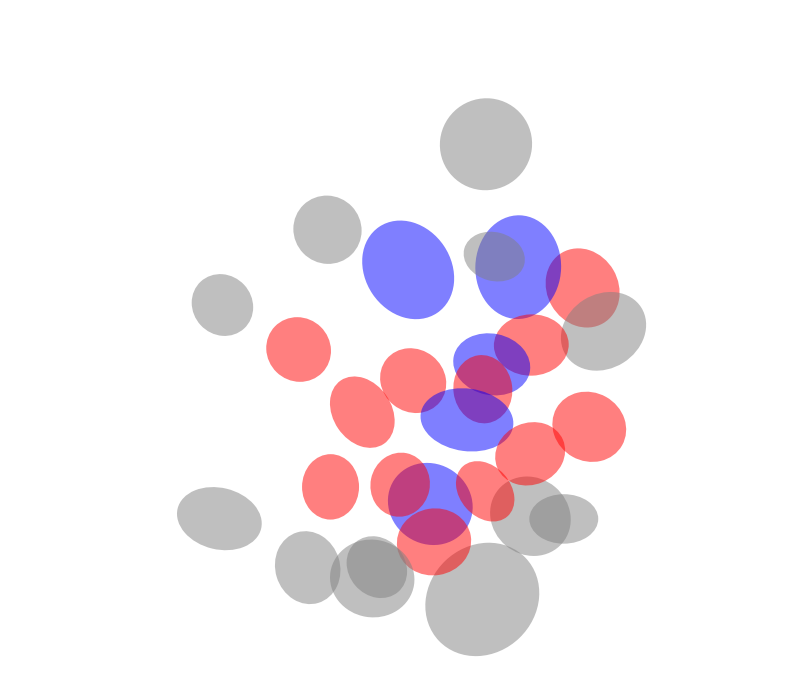

In [1189]:
fig, ax = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(10,10))

assert(vcd.get_runtimemovie_params().pixelsPerStixelX == vcd.get_runtimemovie_params().pixelsPerStixelY)
STIXEL = vcd.get_runtimemovie_params().pixelsPerStixelX

for c in selective_cells:

    center_x = STIXEL * vcd.get_stafit_for_cell(c).center_x
    # center_y = STIXEL * (int(vcd.get_runtimemovie_params().height) - vcd.get_stafit_for_cell(c).center_y)
    center_y = STIXEL * vcd.get_stafit_for_cell(c).center_y
    std_x = STIXEL * vcd.get_stafit_for_cell(c).std_x
    std_y = STIXEL * vcd.get_stafit_for_cell(c).std_y
    rot = vcd.get_stafit_for_cell(c).rot

    rf = Ellipse(xy=(center_x,center_y), width=2*std_x, height=2*std_y, angle=rot*180/np.pi, fill=False, linewidth=2)

    if c in selective_cells_of_interest:
        if c in vcd.get_all_cells_similar_to_type('ON parasol'):
            rf.set_fill(True)
            rf.set_facecolor('blue')
            rf.set_alpha(0.5)
        elif c in vcd.get_all_cells_similar_to_type('OFF parasol'):      
            rf.set_fill(True)
            rf.set_facecolor('red')
            rf.set_alpha(0.5)
    else:
        rf.set_fill(True)
        rf.set_facecolor('gray')
        rf.set_alpha(0.5)
    
    ax.add_patch(rf)

ax.set_xlim(0+250, 640-1-225)
ax.set_ylim(0+75, 320-1-100)
ax.set_aspect('equal')
# ax.set_title(cell_type)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
ax.set_frame_on(False)
ax.invert_yaxis()
plt.show()

In [1190]:
# Build electrically evoked response for a single trial using the spike dictionary
estim_response = [[] for _ in range(len(selective_cells_of_interest))]

for t in range(unique_times.shape[0]):
    for c in spikes[t]:
        if spikes[t][c][estim_trial]:
            estim_response[np.where(selective_cells_of_interest == c)[0][0]].append(unique_times[t])

for c in range(len(estim_response)):
    estim_response[c] = np.array(estim_response[c])
estim_response = np.array(estim_response, dtype=object) / 20 # convert to ms

### Add spontaneous activity to electrically evoked spike trains

In [1191]:
espont_vcd = vl.load_vision_data(espont_path,espont,
                                include_neurons=True)

espont_spike_times = np.array([espont_vcd.get_spike_times_for_cell(c) for c in selective_cells_of_interest], dtype=object)

offset = 20000 # offset of 20000 samples between SEF times and actual data
low = unique_times[0] + offset
high = unique_times[-1] + offset
total_response = np.array([(spike_time[(low < spike_time) & (spike_time < high)] - offset) / 20 for spike_time in espont_spike_times], dtype=object) # convert to ms

In [1192]:
print(f"All spikes found by Vision are")
for c in range(len(total_response)):
    print(f"Cell {selective_cells_of_interest[c]} spikes: {len(total_response[c])}")

All spikes found by Vision are
Cell 3017 spikes: 0
Cell 7175 spikes: 2
Cell 2416 spikes: 1
Cell 2523 spikes: 22
Cell 2117 spikes: 29
Cell 5626 spikes: 5
Cell 5506 spikes: 0
Cell 858 spikes: 11
Cell 4488 spikes: 0
Cell 918 spikes: 27
Cell 406 spikes: 4
Cell 48 spikes: 2
Cell 545 spikes: 0
Cell 3706 spikes: 21
Cell 46 spikes: 0
Cell 2131 spikes: 4
Cell 1401 spikes: 1


In [1193]:
# Get rid of any electrically evoked spikes identified by Vision
# espont_response = [[] for _ in range(len(total_response))]
# for c in range(len(total_response)):
#     espont_response[c] = np.array([spike for spike in total_response[c] if not np.any(((spike - estim_response[c]) >= -1) & ((spike - estim_response[c]) <= 2))])
# espont_response = np.array(espont_response, dtype=object)

In [1194]:
# Get rid of any electrically evoked spikes identified by Vision
espont_response = [[] for _ in range(len(total_response))]
for c in range(len(total_response)):
    espont_response[c] = np.array([spike for spike in total_response[c] if not np.any(((spike - unique_times/20) >= -1) & ((spike - unique_times/20) <= 2))])
espont_response = np.array(espont_response, dtype=object)

In [1195]:
print(f"Spontaneous spikes found by Vision are")
for c in range(len(espont_response)):
    print(f"Cell {selective_cells_of_interest[c]} spikes: {len(espont_response[c])}")

Spontaneous spikes found by Vision are
Cell 3017 spikes: 0
Cell 7175 spikes: 0
Cell 2416 spikes: 0
Cell 2523 spikes: 0
Cell 2117 spikes: 0
Cell 5626 spikes: 0
Cell 5506 spikes: 0
Cell 858 spikes: 0
Cell 4488 spikes: 0
Cell 918 spikes: 0
Cell 406 spikes: 0
Cell 48 spikes: 0
Cell 545 spikes: 0
Cell 3706 spikes: 0
Cell 46 spikes: 0
Cell 2131 spikes: 1
Cell 1401 spikes: 0


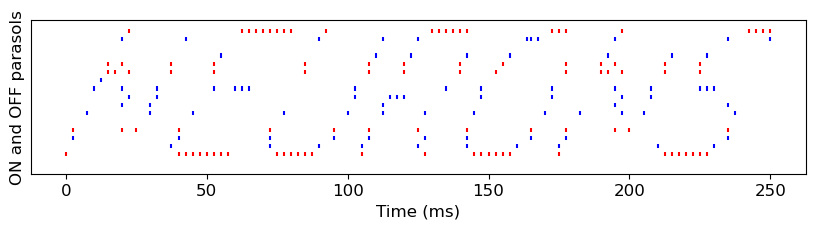

In [1202]:
plt.figure(figsize=(10, 2))

# Create a spike raster plot
plt.eventplot(estim_response-sef_of_interest[0,0]/20, linelengths=0.5, colors=colors)
plt.eventplot(espont_response-sef_of_interest[0,0]/20, linelengths=0.5, colors=colors)

# Set the y-axis ticks and labels
plt.yticks(range(len(selective_cells_of_interest)), true_order)
plt.ylabel('ON and OFF parasols', fontsize=12)

# Set the x-axis label
plt.xlabel('Time (ms)', fontsize=12)

# Make all ticks larger
plt.tick_params(axis='both', which='major', labelsize=12)

# Hide x-axis ticks
# plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

# Hide y-axis ticks
plt.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)

# Set the plot title
# plt.title('Electrically Evoked Spike Trains')

# Save the plot
# plt.savefig(f"/Volumes/Scratch/iko/Users/ajphillips/tmp/brooke/iloveyou.png", dpi=1200, bbox_inches='tight')

# Show the plot
plt.show()

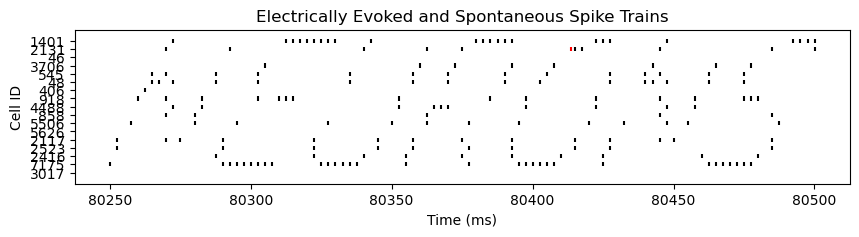

In [1197]:
plt.figure(figsize=(10, 2))

# Create a spike raster plot
plt.eventplot(estim_response, linelengths=0.5, colors='k')
plt.eventplot(espont_response, linelengths=0.5, colors='r')

# Set the y-axis ticks and labels
plt.yticks(range(len(selective_cells_of_interest)), true_order)
plt.ylabel('Cell ID')

# Set the x-axis label
plt.xlabel('Time (ms)')

# Set the plot title
plt.title('Electrically Evoked and Spontaneous Spike Trains')

# Show the plot
plt.show()

### Put it all together and make the money figure

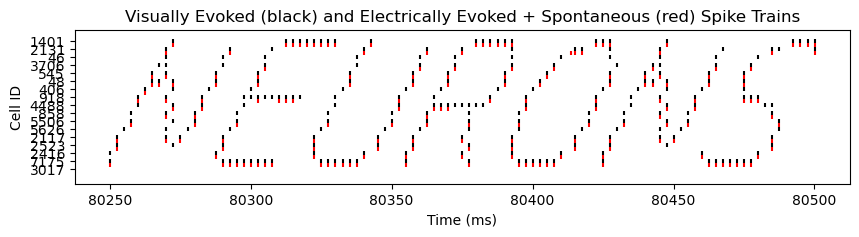

In [1198]:
plt.figure(figsize=(10, 2))

# Make two lineoffsets vectors offset by a constant value
lineoffsets1 = np.arange(len(selective_cells_of_interest))
lineoffsets2 = np.arange(len(selective_cells_of_interest)) - 0.5

# Create a spike raster plot
plt.eventplot(ordered_spike_times, linelengths=0.5, lineoffsets=lineoffsets1, colors='black')
plt.eventplot(estim_response, linelengths=0.5, lineoffsets=lineoffsets2, colors='red')
plt.eventplot(espont_response, linelengths=0.5, lineoffsets=lineoffsets2, colors='red')

# Set the y-axis ticks and labels
plt.yticks(range(len(selective_cells_of_interest)), true_order)
plt.ylabel('Cell ID')

# Set the x-axis label
plt.xlabel('Time (ms)')

# Set the plot title
plt.title('Visually Evoked (black) and Electrically Evoked + Spontaneous (red) Spike Trains')

# Show the plot
plt.show()

In [1199]:
# Find which selective stimulus was used for cell 2312
subset = selective_stimuli[np.where(selective_stimuli[:,1] == 4998)[0]]
print(subset)

[]


In [1200]:
ordering = []
for row in sef_of_interest:
    if transform_to_519(row[1]) in subset[:,0]:
        ordering.append(transform_to_519(row[1]))
print(ordering)

[]


In [1201]:
print(AMPS[bundle_thresholds[np.where(bundle_thresholds[:,0] == 264)[0][0]][1].astype(int)])

NameError: name 'AMPS' is not defined

In [ ]:
AMPS = np.array([0.09375, 0.1875, 0.28125, 0.375, 0.46875, 0.5625, 0.65625, 0.75, 0.84375, 0.9375,
    1.03125, 1.125, 1.21875, 1.3125, 1.40625, 1.5, 1.59375, 1.6875, 1.78125, 1.875, 1.96875,
    2.0625, 2.15625, 2.25, 2.34375, 2.4375, 2.53125, 2.625, 2.71875, 2.8125, 2.90625, 3.0,
    3.09375, 3.1875, 3.28125, 3.375, 3.46875, 3.5625, 3.65625, 3.75, 3.84375, 3.9375])

def transform_to_519_list(patterns):
    skip_elecs = np.array([1, 130, 259, 260, 389, 390, 519])
    elecs = np.arange(1, 520)
    elecs = elecs[~np.isin(elecs, skip_elecs)]

    electrodes = []
    for pattern in patterns:
        electrodes.append(elecs[pattern-1])
    return np.array(electrodes)